In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt

In [2]:
from database import init_engine, get_session

init_engine()
session = get_session()

In [3]:
from feature_selection import *
from dataloader.utils import *
from tqdm import tqdm
import random

In [4]:
import statistics
all_ps = utils.remove_unranked_participants(session.query(Participation).all())
speeds = list(map(calculate_speed, all_ps))
MEAN_SPEED = statistics.mean(speeds)
STD_SPEED = statistics.stdev(speeds)
print(MEAN_SPEED)
print(STD_SPEED)


16.793224828089777
0.4262042064788125


In [5]:
def normalize_speed(speed):
    return (speed - MEAN_SPEED) / STD_SPEED

def get_mean_std(data_x):
    mean = torch.mean(data_x, dim=0)
    std = torch.std(data_x, dim=0)
    std[std == 0] = 1
    return mean, std


In [6]:
def get_train_cv_split(data_keys, cv_ratio=0.1):
    m = len(data_keys)
    train_size = round(m * (1 - cv_ratio))
    train_keys = set(random.sample(data_keys, train_size))
    cv_keys = set(data_keys) - set(train_keys)
    return list(train_keys), list(cv_keys)

In [7]:
def calculate_cost(model, target_keys, data_x, data_y, settings):
    criterion = model.criterion()
    train_mean = settings["train_mean"]
    train_std = settings["train_std"]
    total_cost = 0
    for key in target_keys:
        this_x = torch.tensor(data_x[key], dtype=torch.float32, device="cuda")
        this_y = torch.tensor(data_y[key], dtype=torch.float32, device="cuda")
        normalized_x = (this_x - train_mean) / train_std

        output = model(normalized_x)
        loss = criterion(output, this_y)
        try:
            assert not torch.isnan(loss).any()
        except AssertionError:
            print(loss)
            print(output)
            print(this_y)
            input()
        total_cost += loss.item()

    return total_cost / len(target_keys)


In [8]:
def load_data(size, f, distance, train_mode=True):
    if train_mode:
        start_date = datetime(2012, 9, 1)
        end_date = datetime(2022, 9, 1)
    else:
        start_date = datetime(2022, 9, 1)
        end_date = datetime(2024, 9, 1)

    races = (session.query(Race).filter(Race.date >= start_date).filter(Race.date < end_date)
             .filter(Race.distance == distance)
             .all())
    all_x = {}
    horse_nums = {}
    all_y = {}
    winner = {}
    place = {}
    for race in tqdm(races, desc="Loading races"):
        ps = get_relevant_ps_from_race(race)
        total = len(utils.remove_unranked_participants(race.participations))
        m = len(ps)
        if total - m >= 3 or m < 5:
            continue

        this_x = np.zeros((m, size), dtype=np.float32)
        this_horse_nums = np.zeros(m, dtype=int)
        this_y = np.zeros((m, 1), dtype=np.float32)

        for i, p in enumerate(ps):
            this_x[i] = f(p)
            this_horse_nums[i] = p.number
            ranking = get_ranking_from_participation(p)
            this_y[i, 0] = convert_ranking_to_score(ranking)

        all_x[race.id] = this_x
        all_y[race.id] = this_y
        horse_nums[race.id] = this_horse_nums

        this_winnings = race.winnings
        for winning in this_winnings:
            if winning.pool == "WIN":
                if race.id not in winner:
                    winner[race.id] = []
                winner[race.id].append(int(winning.combination))
            elif winning.pool == "PLACE":
                if race.id not in place:
                    place[race.id] = []
                place[race.id].append(int(winning.combination))

    no_nan = True
    for key in all_x:
        this_x = all_x[key]
        if np.isnan(this_x).any():
            no_nan = False
            break

    print(f"No nan: {no_nan}")

    return all_x, all_y, horse_nums, winner, place

In [9]:
def group_settings(train_keys, cv_keys, train_mean, train_std, epochs):
    return {
        "train_keys": train_keys,
        "cv_keys": cv_keys,
        "train_mean": train_mean,
        "train_std": train_std,
        "epochs": epochs,
    }

In [10]:
def perform_prediction(model, normalized_x, horse_nums):
    model.eval()
    predictions = model(normalized_x)
    bet = horse_nums[torch.argmax(predictions)]
    return bet


In [11]:
def test_accuracy(model, data_x, horse_nums, winner_horses, place_horses, settings):
    train_mean = settings["train_mean"]
    train_std = settings["train_std"]
    winner_count = 0
    place_count = 0
    total_count = 0
    for key in data_x:
        this_x = torch.tensor(data_x[key], dtype=torch.float32, device="cuda")
        normalized_x = (this_x - train_mean) / train_std
        prediction = perform_prediction(model, normalized_x, horse_nums[key])
        if prediction in winner_horses[key]:
            winner_count += 1
        if prediction in place_horses[key]:
            place_count += 1
        total_count += 1

    return winner_count, place_count, total_count


In [12]:
def prepare_training(features_size, data_x):
    train_keys, cv_keys = get_train_cv_split(list(data_x.keys()))

    # get calculate_train_size
    train_size = 0
    for key in train_keys:
        train_size += data_x[key].shape[0]

    train_x = np.zeros((train_size, features_size), dtype=np.float32)
    counter = 0
    for key in train_keys:
        current_x = data_x[key]
        current_m = current_x.shape[0]
        train_x[counter:counter + current_m] = current_x
        counter += current_m

    train_x = torch.tensor(train_x, dtype=torch.float32, device="cuda")
    train_mean, train_std = get_mean_std(train_x)

    return train_mean, train_std, train_keys, cv_keys

In [13]:
def train_model(model, data_x, data_y, settings):
    train_mean = settings["train_mean"]
    train_std = settings["train_std"]
    train_keys = settings["train_keys"]
    cv_keys = settings["cv_keys"]
    epochs = settings["epochs"]

    model.eval()
    initial_train_cost = calculate_cost(model, train_keys, data_x, data_y, settings)
    initial_cv_cost = calculate_cost(model, cv_keys, data_x, data_y, settings)
    print(f"Initial cost: {initial_train_cost}. CV cost: {initial_cv_cost}")

    train_hist = []
    cv_hist = []

    criterion = model.criterion()
    optimizer = model.optimizer()
    for epoch in range(epochs):
        model.train()
        for key in train_keys:
            this_x = torch.tensor(data_x[key], dtype=torch.float32, device="cuda")
            this_y = torch.tensor(data_y[key], dtype=torch.float32, device="cuda")
            normalized_x = (this_x - train_mean) / train_std
            output = model(normalized_x)
            loss = criterion(output, this_y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        model.eval()
        train_cost = calculate_cost(model, train_keys, data_x, data_y, settings)
        cv_cost = calculate_cost(model, cv_keys, data_x, data_y, settings)
        train_hist.append(train_cost)
        cv_hist.append(cv_cost)
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch + 1}/{epochs} - train cost = {train_cost:.5f}, cv cost: {cv_cost:.5f}")

    return train_hist, cv_hist


In [14]:
def display_accuracy(header, accuracy):
    win_count, place_count, total_count = accuracy
    print(f"======== Stats for {header} ========")
    print(f"Winner accuracy: {win_count / total_count * 100:.2f}%")
    print(f"Place accuracy: {place_count / total_count * 100:.2f}%")

In [15]:
random_data, _, random_h_nums, random_winner_horses, random_place_horses = load_data(0, lambda x: np.array([]), distance=1400, train_mode=False)

random_winner_correct = 0
random_place_correct = 0
for test_key in random_h_nums:
    random_winner = random.choice(random_h_nums[test_key])
    if random_winner == random_winner_horses[test_key]:
        random_winner_correct += 1
    if random_winner in random_place_horses[test_key]:
        random_place_correct += 1

display_accuracy("Random data", (random_winner_correct, random_place_correct, len(random_data)))

Loading races: 100%|██████████| 265/265 [00:01<00:00, 191.93it/s]

No nan: True
======== Stats for Random data ========
Winner accuracy: 5.04%
Place accuracy: 21.71%


In [16]:
def plot_cost_history_graph(train_hist, cv_hist):
    x_axis = list(range(len(train_hist)))
    plt.plot(x_axis, train_hist, label="Training data")
    plt.plot(x_axis, cv_hist, label="Test data")
    plt.legend()
    plt.xlabel("Epoch")
    plt.ylabel("Cost")
    plt.show()


def experiment_features(model, features_size, f, distance, epochs):
    model = model.to("cuda")
    data_x, data_y, horse_nums, winner_horses, place_horses = load_data(features_size, f, distance, train_mode=True)
    test_data, _, test_h_nums, test_winner_horses, test_place_horses = load_data(features_size, f, distance, train_mode=False)
    train_mean, train_std, train_keys, cv_keys = prepare_training(features_size, data_x)
    print(f"Training model on {len(train_keys)} races.")
    settings = group_settings(train_keys, cv_keys, train_mean, train_std, epochs)

    train_hist, cv_hist = train_model(model, data_x, data_y, settings)
    plot_cost_history_graph(train_hist, cv_hist)

    data_accuracy = test_accuracy(model, data_x, horse_nums, winner_horses, place_horses, settings)
    test_data_accuracy = test_accuracy(model, test_data, test_h_nums, test_winner_horses, test_place_horses, settings)
    display_accuracy("Train data", data_accuracy)
    display_accuracy("Test data", test_data_accuracy)


In [17]:
class OneFeatureRegressor(nn.Module):
    def __init__(self):
        super(OneFeatureRegressor, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(1, 1)
        )

    def forward(self, x):
        return self.model(x)

    @staticmethod
    def criterion():
        return nn.MSELoss()

    def optimizer(self):
        return optim.SGD(self.model.parameters(), lr=0.001, momentum=0.9)

def load_one_feature(p):
    return np.array([p.rating], dtype=np.float32)

experiment_features(OneFeatureRegressor().to("cuda"), 1, load_one_feature, distance=1400, epochs=10)

Loading races: 100%|██████████| 1321/1321 [00:06<00:00, 200.45it/s]


No nan: True


Loading races: 100%|██████████| 265/265 [00:00<00:00, 3819.53it/s]


No nan: True
Training model on 1122 races.


KeyboardInterrupt: 

Loading races: 100%|██████████| 1065/1065 [00:00<00:00, 3054.29it/s]


No nan: True


Loading races: 100%|██████████| 265/265 [00:00<00:00, 4028.31it/s]


No nan: True
Training model on 901 races.
Initial cost: 0.3599587277520642. CV cost: 0.33648223340511324
Epoch 10/100 - train cost = 0.11996, cv cost: 0.11803
Epoch 20/100 - train cost = 0.11994, cv cost: 0.11806
Epoch 30/100 - train cost = 0.11993, cv cost: 0.11807
Epoch 40/100 - train cost = 0.11993, cv cost: 0.11808
Epoch 50/100 - train cost = 0.11992, cv cost: 0.11809
Epoch 60/100 - train cost = 0.11992, cv cost: 0.11810
Epoch 70/100 - train cost = 0.11991, cv cost: 0.11812
Epoch 80/100 - train cost = 0.11991, cv cost: 0.11813
Epoch 90/100 - train cost = 0.11990, cv cost: 0.11815
Epoch 100/100 - train cost = 0.11990, cv cost: 0.11818


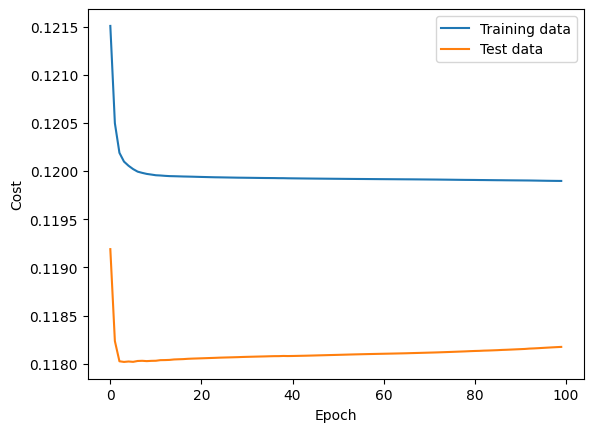

======== Stats for Train data ========
Winner accuracy: 11.49%
Place accuracy: 31.47%
======== Stats for Test data ========
Winner accuracy: 10.08%
Place accuracy: 31.78%


In [77]:
class TwoFeatureRegressor(nn.Module):
    def __init__(self):
        super(TwoFeatureRegressor, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(2, 3),
            nn.ReLU(),
            nn.Linear(3, 1)
        )

    def forward(self, x):
        return self.model(x)

    @staticmethod
    def criterion():
        return nn.MSELoss()

    def optimizer(self):
        return optim.SGD(self.model.parameters(), lr=0.001, momentum=0.9)

def load_two_feature(p):
    return np.array([p.rating, p.horse_weight], dtype=np.float32)

experiment_features(TwoFeatureRegressor(), 2, load_two_feature, distance=1400, epochs=100)

Loading races: 100%|██████████| 1065/1065 [00:00<00:00, 2502.98it/s]


No nan: True


Loading races: 100%|██████████| 265/265 [00:00<00:00, 3680.24it/s]


No nan: True
Training model on 901 races.
Initial cost: 0.45822802418377767. CV cost: 0.46054034546017647
Epoch 10/100 - train cost = 0.11892, cv cost: 0.12038
Epoch 20/100 - train cost = 0.11882, cv cost: 0.12050
Epoch 30/100 - train cost = 0.11881, cv cost: 0.12054
Epoch 40/100 - train cost = 0.11881, cv cost: 0.12052
Epoch 50/100 - train cost = 0.11879, cv cost: 0.12056
Epoch 60/100 - train cost = 0.11875, cv cost: 0.12053
Epoch 70/100 - train cost = 0.11874, cv cost: 0.12056
Epoch 80/100 - train cost = 0.11874, cv cost: 0.12057
Epoch 90/100 - train cost = 0.11875, cv cost: 0.12059
Epoch 100/100 - train cost = 0.11874, cv cost: 0.12060


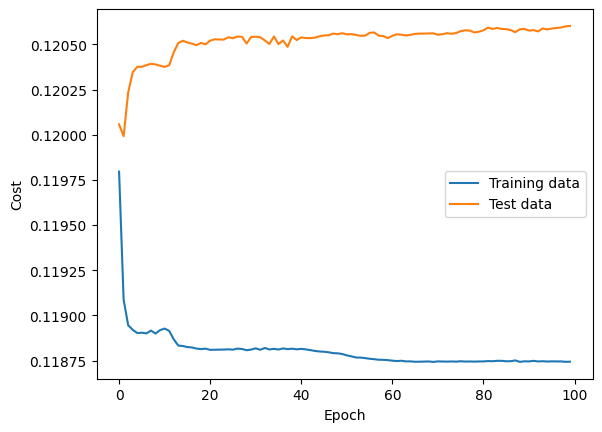

======== Stats for Train data ========
Winner accuracy: 13.59%
Place accuracy: 33.67%
======== Stats for Test data ========
Winner accuracy: 11.24%
Place accuracy: 25.19%


In [78]:
class ThreeFeatureRegressor(nn.Module):
    def __init__(self):
        super(ThreeFeatureRegressor, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(3, 4),
            nn.ReLU(),
            nn.Linear(4, 1)
        )

    def forward(self, x):
        return self.model(x)

    @staticmethod
    def criterion():
        return nn.MSELoss()

    def optimizer(self):
        return optim.Adam(self.model.parameters(), lr=0.001, weight_decay=5e-4)

def load_three_feature(p):
    return np.array([p.rating, p.horse_weight, p.lane], dtype=np.float32)

experiment_features(ThreeFeatureRegressor(), 3, load_three_feature, distance=1400, epochs=100)

Loading races: 100%|██████████| 1065/1065 [00:00<00:00, 1816.77it/s]


No nan: True


Loading races: 100%|██████████| 265/265 [00:00<00:00, 2308.85it/s]


No nan: True
Training model on 901 races.
Initial cost: 0.20473360005232788. CV cost: 0.21815971303731202
Epoch 10/100 - train cost = 0.11860, cv cost: 0.11690
Epoch 20/100 - train cost = 0.11859, cv cost: 0.11688
Epoch 30/100 - train cost = 0.11827, cv cost: 0.11658
Epoch 40/100 - train cost = 0.11821, cv cost: 0.11662
Epoch 50/100 - train cost = 0.11820, cv cost: 0.11676
Epoch 60/100 - train cost = 0.11818, cv cost: 0.11675
Epoch 70/100 - train cost = 0.11818, cv cost: 0.11672
Epoch 80/100 - train cost = 0.11816, cv cost: 0.11674
Epoch 90/100 - train cost = 0.11815, cv cost: 0.11678
Epoch 100/100 - train cost = 0.11815, cv cost: 0.11676


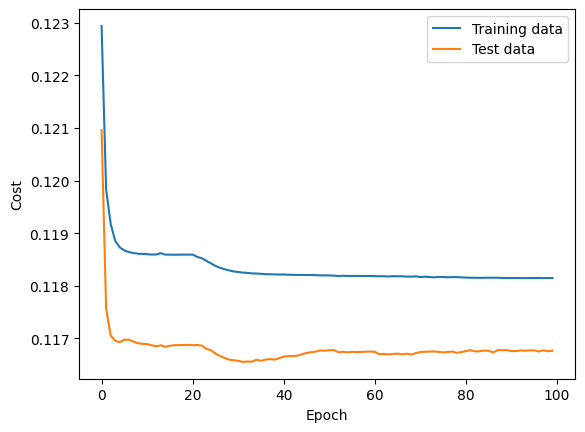

======== Stats for Train data ========
Winner accuracy: 13.69%
Place accuracy: 35.06%
======== Stats for Test data ========
Winner accuracy: 12.40%
Place accuracy: 32.56%


In [79]:
class FourFeatureRegressor(nn.Module):
    def __init__(self):
        super(FourFeatureRegressor, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(4, 5),
            nn.ReLU(),
            nn.Linear(5, 1)
        )

    def forward(self, x):
        return self.model(x)

    @staticmethod
    def criterion():
        return nn.MSELoss()

    def optimizer(self):
        return optim.Adam(self.model.parameters(), lr=0.001, weight_decay=8e-4)

def load_four_features(p):
    latest_horse_p = get_latest_horse_p(p)
    return np.array([p.rating, p.horse_weight, p.lane, calculate_speed(latest_horse_p)], dtype=np.float32)

experiment_features(FourFeatureRegressor(), 4, load_four_features, distance=1400, epochs=100)


Loading races: 100%|██████████| 1065/1065 [00:00<00:00, 1233.90it/s]


No nan: True


Loading races: 100%|██████████| 265/265 [00:00<00:00, 1596.44it/s]


No nan: True
Training model on 901 races.
Initial cost: 0.1425956480171982. CV cost: 0.14422286726534367
Epoch 10/100 - train cost = 0.12764, cv cost: 0.12606
Epoch 20/100 - train cost = 0.12618, cv cost: 0.12498
Epoch 30/100 - train cost = 0.12537, cv cost: 0.12462
Epoch 40/100 - train cost = 0.12551, cv cost: 0.12476
Epoch 50/100 - train cost = 0.12558, cv cost: 0.12481
Epoch 60/100 - train cost = 0.12577, cv cost: 0.12485
Epoch 70/100 - train cost = 0.12612, cv cost: 0.12513
Epoch 80/100 - train cost = 0.12595, cv cost: 0.12501
Epoch 90/100 - train cost = 0.12605, cv cost: 0.12505
Epoch 100/100 - train cost = 0.12611, cv cost: 0.12511


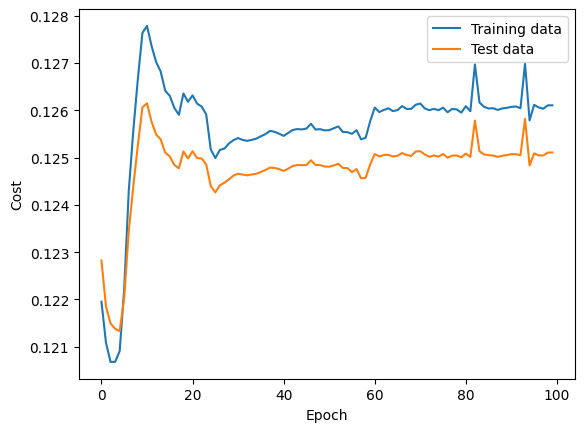

======== Stats for Train data ========
Winner accuracy: 14.79%
Place accuracy: 38.36%
======== Stats for Test data ========
Winner accuracy: 10.85%
Place accuracy: 34.11%


In [80]:
class FiveFeatureRegressor(nn.Module):
    def __init__(self):
        super(FiveFeatureRegressor, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(5, 6),
            nn.BatchNorm1d(6),
            nn.ReLU(),
            nn.Linear(6, 1)
        )

    def forward(self, x):
        return self.model(x)

    @staticmethod
    def criterion():
        return nn.MSELoss()

    def optimizer(self):
        return optim.Adam(self.model.parameters(), lr=0.001, weight_decay=8e-4)

def load_five_features(p):
    latest_horse_p = get_latest_horse_p(p)
    return np.array([p.rating, p.horse_weight, p.lane, calculate_speed(latest_horse_p), count_number_of_previous_races(p)], dtype=np.float32)

experiment_features(FiveFeatureRegressor(), 5, load_five_features, distance=1400, epochs=100)

Loading races: 100%|██████████| 1065/1065 [00:00<00:00, 1281.07it/s]


No nan: True


Loading races: 100%|██████████| 265/265 [00:00<00:00, 1659.89it/s]


No nan: True
Training model on 901 races.
Initial cost: 0.24597335840005854. CV cost: 0.24429449021816255
Epoch 10/100 - train cost = 0.11450, cv cost: 0.11728
Epoch 20/100 - train cost = 0.11396, cv cost: 0.11680
Epoch 30/100 - train cost = 0.11383, cv cost: 0.11663
Epoch 40/100 - train cost = 0.11392, cv cost: 0.11654
Epoch 50/100 - train cost = 0.11391, cv cost: 0.11663
Epoch 60/100 - train cost = 0.11385, cv cost: 0.11651
Epoch 70/100 - train cost = 0.11389, cv cost: 0.11661
Epoch 80/100 - train cost = 0.11393, cv cost: 0.11672
Epoch 90/100 - train cost = 0.11375, cv cost: 0.11654
Epoch 100/100 - train cost = 0.11380, cv cost: 0.11647


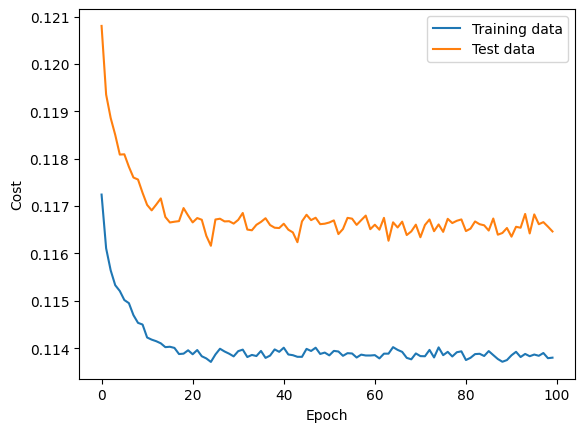

======== Stats for Train data ========
Winner accuracy: 16.78%
Place accuracy: 43.56%
======== Stats for Test data ========
Winner accuracy: 14.73%
Place accuracy: 34.11%


In [81]:
class EightFeatureRegressor(nn.Module):
    def __init__(self):
        super(EightFeatureRegressor, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(8, 4),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(4, 1)
        )

    def forward(self, x):
        return self.model(x)

    @staticmethod
    def criterion():
        return nn.MSELoss()

    def optimizer(self):
        return optim.Adam(self.model.parameters(), lr=0.001, weight_decay=0.001)

def load_eight_features(p):
    latest_horse_p = get_latest_horse_p(p)
    return np.array([
        p.rating,
        p.horse_weight,
        p.lane,
        p.number,
        calculate_speed(latest_horse_p),
        count_number_of_previous_races(p),
        convert_race_class(p.race.race_class),
        convert_ranking_to_score(get_ranking_from_participation(latest_horse_p))
    ], dtype=np.float32)

experiment_features(EightFeatureRegressor(), 8, load_eight_features, distance=1400, epochs=100)

Loading races: 100%|██████████| 1065/1065 [00:00<00:00, 1257.91it/s]


No nan: True


Loading races: 100%|██████████| 265/265 [00:00<00:00, 1608.48it/s]


No nan: True
Training model on 901 races.
Initial cost: 0.21774949249165437. CV cost: 0.22766383975744248
Epoch 10/150 - train cost = 0.11500, cv cost: 0.11777
Epoch 20/150 - train cost = 0.11414, cv cost: 0.11733
Epoch 30/150 - train cost = 0.11371, cv cost: 0.11651
Epoch 40/150 - train cost = 0.11306, cv cost: 0.11566
Epoch 50/150 - train cost = 0.11247, cv cost: 0.11508
Epoch 60/150 - train cost = 0.11192, cv cost: 0.11433
Epoch 70/150 - train cost = 0.11147, cv cost: 0.11375
Epoch 80/150 - train cost = 0.11136, cv cost: 0.11376
Epoch 90/150 - train cost = 0.11122, cv cost: 0.11361
Epoch 100/150 - train cost = 0.11099, cv cost: 0.11357
Epoch 110/150 - train cost = 0.11091, cv cost: 0.11344
Epoch 120/150 - train cost = 0.11076, cv cost: 0.11330
Epoch 130/150 - train cost = 0.11071, cv cost: 0.11296
Epoch 140/150 - train cost = 0.11064, cv cost: 0.11334
Epoch 150/150 - train cost = 0.11055, cv cost: 0.11316


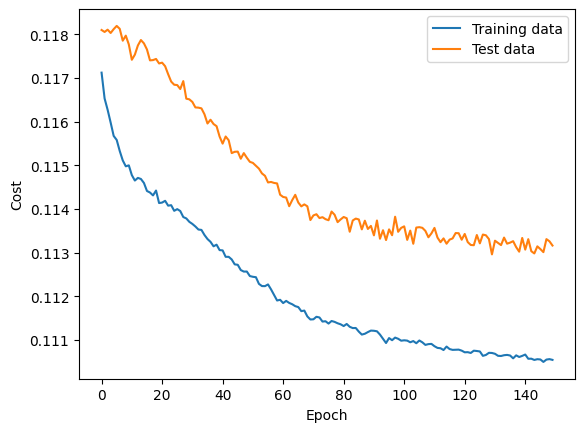

======== Stats for Train data ========
Winner accuracy: 18.78%
Place accuracy: 46.35%
======== Stats for Test data ========
Winner accuracy: 13.57%
Place accuracy: 36.82%


In [82]:
class TwelveFeatureRegressor(nn.Module):
    def __init__(self):
        super(TwelveFeatureRegressor, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(12, 6),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(6, 1)
        )

    def forward(self, x):
        return self.model(x)

    @staticmethod
    def criterion():
        return nn.MSELoss()

    def optimizer(self):
        return optim.SGD(self.model.parameters(), lr=0.001, weight_decay=0.0005, momentum=0.9)


def load_twelve_features(p):
    latest_horse_p = get_latest_horse_p(p)
    return np.array([
        p.rating,
        p.rating - (latest_horse_p.rating if latest_horse_p.rating is not None else 25),
        p.horse_weight,
        p.horse_weight - latest_horse_p.horse_weight,
        p.gear_weight,
        p.lane,
        p.number,
        calculate_speed(latest_horse_p),
        count_number_of_previous_races(p),
        convert_race_class(p.race.race_class),
        convert_ranking_to_score(get_ranking_from_participation(latest_horse_p)),
        latest_horse_p.win_odds
    ], dtype=np.float32)

experiment_features(TwelveFeatureRegressor(), 12, load_twelve_features, distance=1400, epochs=150)
# best result: test accuracy = 19.38%

Loading races: 100%|██████████| 1065/1065 [00:06<00:00, 165.78it/s]


No nan: True


Loading races: 100%|██████████| 265/265 [00:01<00:00, 215.16it/s]


No nan: True
Training model on 901 races.
Initial cost: 0.5547142589297331. CV cost: 0.548038306236267
Epoch 10/100 - train cost = 0.11462, cv cost: 0.11449
Epoch 20/100 - train cost = 0.11373, cv cost: 0.11428
Epoch 30/100 - train cost = 0.11317, cv cost: 0.11433
Epoch 40/100 - train cost = 0.11268, cv cost: 0.11422
Epoch 50/100 - train cost = 0.11228, cv cost: 0.11413
Epoch 60/100 - train cost = 0.11197, cv cost: 0.11416
Epoch 70/100 - train cost = 0.11171, cv cost: 0.11417
Epoch 80/100 - train cost = 0.11146, cv cost: 0.11416
Epoch 90/100 - train cost = 0.11122, cv cost: 0.11384
Epoch 100/100 - train cost = 0.11081, cv cost: 0.11353


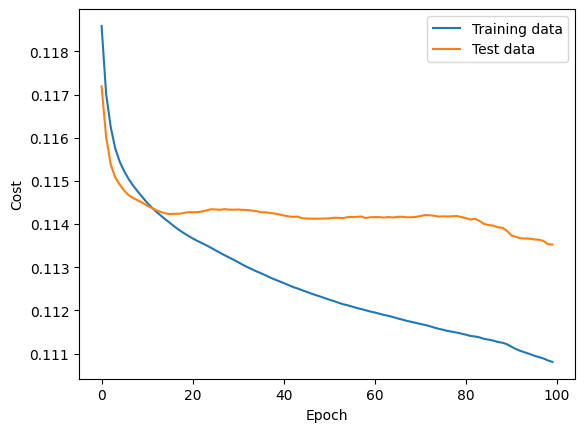

======== Stats for Train data ========
Winner accuracy: 19.38%
Place accuracy: 48.15%
======== Stats for Test data ========
Winner accuracy: 16.28%
Place accuracy: 37.98%


In [93]:
class SixteenFeatureRegressor(nn.Module):
    def __init__(self):
        super(SixteenFeatureRegressor, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 1)
        )

    def forward(self, x):
        return self.model(x)

    @staticmethod
    def criterion():
        return nn.MSELoss()

    def optimizer(self):
        return optim.SGD(self.model.parameters(), lr=0.001, momentum=0.9)


def load_sixteen_features(p):
    latest_horse_p = get_latest_horse_p(p)
    avg_rating = get_average_rating(p.race)
    rating_min, rating_max = get_min_max_rating(p.race)
    old_score = convert_ranking_to_score(get_ranking_from_participation(latest_horse_p))
    return np.array([
        p.rating,
        p.rating - (latest_horse_p.rating if latest_horse_p.rating is not None else 25),
        p.rating - avg_rating,
        p.rating - rating_min,
        rating_max - p.rating,
        p.rating / convert_race_class(p.race.race_class),
        p.horse_weight,
        p.horse_weight - latest_horse_p.horse_weight,
        p.gear_weight,
        p.lane,
        p.number,
        calculate_speed(latest_horse_p),
        count_number_of_previous_races(p),
        convert_race_class(p.race.race_class),
        old_score,
        latest_horse_p.win_odds,
    ], dtype=np.float32)


experiment_features(SixteenFeatureRegressor(), 16, load_sixteen_features, distance=1400, epochs=100)
#======== Stats for Train data ========
# Winner accuracy: 20.58%
# Place accuracy: 49.55%
# ======== Stats for Test data ========
# Winner accuracy: 18.22%
# Place accuracy: 40.70%


Loading races: 100%|██████████| 1321/1321 [00:15<00:00, 85.33it/s] 


No nan: True


Loading races: 100%|██████████| 265/265 [00:02<00:00, 99.10it/s] 


No nan: True
Training model on 1122 races.
Initial cost: 0.17259004656989094. CV cost: 0.17117714512348176
Epoch 10/300 - train cost = 0.11328, cv cost: 0.11161
Epoch 20/300 - train cost = 0.11263, cv cost: 0.11100
Epoch 30/300 - train cost = 0.11255, cv cost: 0.11091
Epoch 40/300 - train cost = 0.11251, cv cost: 0.11085
Epoch 50/300 - train cost = 0.11249, cv cost: 0.11084
Epoch 60/300 - train cost = 0.11246, cv cost: 0.11084
Epoch 70/300 - train cost = 0.11245, cv cost: 0.11083
Epoch 80/300 - train cost = 0.11244, cv cost: 0.11084
Epoch 90/300 - train cost = 0.11243, cv cost: 0.11082
Epoch 100/300 - train cost = 0.11242, cv cost: 0.11084
Epoch 110/300 - train cost = 0.11241, cv cost: 0.11083
Epoch 120/300 - train cost = 0.11240, cv cost: 0.11082
Epoch 130/300 - train cost = 0.11239, cv cost: 0.11083
Epoch 140/300 - train cost = 0.11238, cv cost: 0.11083
Epoch 150/300 - train cost = 0.11238, cv cost: 0.11083
Epoch 160/300 - train cost = 0.11237, cv cost: 0.11083
Epoch 170/300 - train 

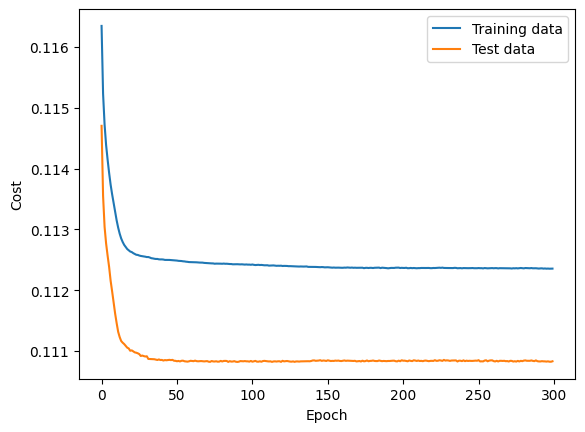

======== Stats for Train data ========
Winner accuracy: 18.20%
Place accuracy: 44.91%
======== Stats for Test data ========
Winner accuracy: 13.18%
Place accuracy: 38.37%


In [18]:
class TwentyFeaturesRegressor(nn.Module):
    def __init__(self):
        super(TwentyFeaturesRegressor, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(20, 8),
            nn.ReLU(),
            nn.Linear(8, 1)
        )

    def forward(self, x):
        return self.model(x)

    @staticmethod
    def criterion():
        return nn.MSELoss()

    def optimizer(self):
        return optim.SGD(self.model.parameters(), lr=0.001, momentum=0.9, weight_decay=0.01)


def load_twenty_features(p):
    latest_horse_p = get_latest_horse_p(p)
    avg_rating = get_average_rating(p.race)
    rating_min, rating_max = get_min_max_rating(p.race)
    old_score = convert_ranking_to_score(get_ranking_from_participation(latest_horse_p))
    number_of_participants = get_number_of_participants(p.race)
    return np.array([
        p.rating,
        p.rating - (latest_horse_p.rating if latest_horse_p.rating is not None else 25),
        p.rating - avg_rating,
        p.rating - rating_min,
        rating_max - p.rating,
        p.rating / convert_race_class(p.race.race_class),
        p.horse_weight,
        p.horse_weight - latest_horse_p.horse_weight,
        p.gear_weight,
        p.gear_weight / (p.gear_weight + p.horse_weight),
        p.lane,
        p.lane / number_of_participants,
        p.number,
        p.number / number_of_participants,
        calculate_defeated_rating(latest_horse_p),
        calculate_speed(latest_horse_p),
        count_number_of_previous_races(p),
        convert_race_class(p.race.race_class),
        old_score,
        1 / latest_horse_p.win_odds,
    ], dtype=np.float32)


experiment_features(TwentyFeaturesRegressor(), 20, load_twenty_features, distance=1400, epochs=300)

In [111]:
race = session.query(Race).filter(Race.id == "2020:563").one()
relevant = get_relevant_ps_from_race(race)
total = len(utils.remove_unranked_participants(race.participations))
print(len(relevant))
print(total)

0
6
